In [1]:
##prepare environment
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle
from math import trunc
import sys


print("Python version:", sys.version)
print("NumPy version:", np.__version__)

sourceDirectory = '../delfic_output/'
#sourceDirectory = 'C:\\Users\\kev\\documents\\DELFIC\\'              
#plotDirectory = 'C:\\Users\\kev\\OneDrive - West Point\\23 Projects\\23.02 SCRAM\\2. LISAT Publish\\figs\\'
#build a list of all the folders in the source directory
import os
falloutFields = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

print(len(falloutFields))

def uniform_sample_ellipse(a, b, theta, num_points):
    """
    Uniformly sample points from an ellipse.
    
    Parameters:
    a (float): Semi-major axis
    b (float): Semi-minor axis
    theta (float): Rotation angle of the ellipse (in radians)
    num_points (int): Number of points to sample
    
    Returns:
    np.ndarray: Sampled points (num_points, 2)
    """
    # Generate uniform points in a unit circle
    angles = np.random.uniform(0, 2 * np.pi, num_points)
    radii = np.sqrt(np.random.uniform(0, 1, num_points))
    
    # Convert to Cartesian coordinates
    x_unit = radii * np.cos(angles)
    y_unit = radii * np.sin(angles)
    
    # Scale points to the ellipse
    x_ellipse = a * x_unit
    y_ellipse = b * y_unit
    
    # Rotate points by theta
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    x_rot = cos_theta * x_ellipse - sin_theta * y_ellipse
    y_rot = sin_theta * x_ellipse + cos_theta * y_ellipse
    
    # Combine and return
    return np.vstack((x_rot, y_rot)).T

Python version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
NumPy version: 1.26.4
160


In [2]:
#of all of the fallout fields, if a folder does not contain a pkl file then print the folder name
for falloutField in falloutFields:
    if not os.path.exists(sourceDirectory + falloutField + f'/{falloutField}.pkl'):
        print(falloutField)

In [3]:
##open the pickle file, and return the data and prodominant fallout direction

def getFieldData(falloutField,sourceDirectory=sourceDirectory):
  with open(sourceDirectory + falloutField + f'/{falloutField}.pkl', 'rb') as f:
    #data is an np.array of shape (timestep, x, y)
    data = pickle.load(f)
  
  #use only a subsection of the first time step to determine the direction
  truncDataScale = 50
  truncDataLowerLimit = data.shape[1]//2 - truncDataScale//2 
  truncData = data[0,truncDataLowerLimit:truncDataLowerLimit+truncDataScale, truncDataLowerLimit:truncDataLowerLimit+truncDataScale]

  # Define a threshold for significant traffic
  minThreshold = 0.1 * np.max(truncData)
  maxThreshold = 0.9 * np.max(truncData)
  # apply the min and max threshold
  falloutIndices = np.nonzero((truncData > minThreshold) & (truncData < maxThreshold))
  falloutX = np.array(falloutIndices[1])
  falloutY = np.array(falloutIndices[0])
  weights = truncData[falloutY, falloutX]  # Use exposure data as weights

  # Calculate the center of the grid
  truncCenterX = (truncData.shape[1] - 1) / 2
  truncCenterY = (truncData.shape[0] - 1) / 2

  # Convert to polar coordinates relative to the center
  angles = np.arctan2(falloutY - truncCenterY, falloutX - truncCenterX)

  # Compute the weighted average angle
  falloutDir = np.arctan2(np.sum(np.sin(angles) * weights), np.sum(np.cos(angles) * weights))

  return data, falloutDir


In [4]:
##plot the fallout field
cmap = plt.cm.jet
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[0] = (1, 1, 1, 1.0)
cmap = mcolors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)

##plotting function
def plotField(radfield, falloutDirection, pixelScale=1, gridScale=1, visibleRadius=None, plotCenter=None,addLine=True) -> plt.Figure:
  #scale provides the units per pixel
  #visibleRadius provides the radius of the visible area in km
  # if visibleRadius is None, the entire field is shown
  plt.figure(figsize=(10, 10))
  ax = plt.gca()
  fig = plt.gcf()
  extent = (0, radfield.shape[1]*pixelScale, 0, radfield.shape[0]*pixelScale)
  im = ax.imshow(radfield, origin='lower', cmap=cmap, alpha=0.5, extent=extent)
  colorbar = fig.colorbar(im, ax=ax, orientation='vertical',shrink=0.6)
  colorbar.set_label('Exposure Rate [R/hr]')

  # Create a line that originates from the center of the field and extends 
  # along the angle provided by the falloutDirection parameter [radians]
  center = np.array(radfield.shape) / 2 * pixelScale
  radius = min(center) * .8
  end = center + radius * np.array([np.sin(falloutDirection), np.cos(falloutDirection)])
  if addLine:
    ax.plot([center[1], end[1]], [center[0], end[0]], 'r-')

  # add a 1km square grid to the plot, 10 units per km
  ax.grid(which='both', color='black', linestyle='-', linewidth=0.5)
  ax.set_xticks(np.arange(0, radfield.shape[1]*pixelScale, gridScale))
  ax.set_yticks(np.arange(0, radfield.shape[0]*pixelScale, gridScale))

  if plotCenter is None:
    plotCenter = center
  else:
    plotCenter = np.array([plotCenter[1], plotCenter[0]])

  # set the visible area of the plot
  if visibleRadius is not None:
    ax.set_xlim(plotCenter[1] - visibleRadius, plotCenter[1] + visibleRadius)
    ax.set_ylim(plotCenter[0] - visibleRadius, plotCenter[0] + visibleRadius)

  return fig

In [5]:
##plot the gate locations
def plotGateways(fig, gateways, detFieldCenter=None, params=None):
  ax = fig.gca()
  for gateway in gateways:
    ax.plot(gateway[0], gateway[1], 'kx')
  if detFieldCenter is not None and params is not None:
    #plot two black circles to represent the gateway limits about the center
    ax.add_artist(plt.Circle(detFieldCenter, params['GatewayMinRange'], color='black', fill=False))
    ax.add_artist(plt.Circle(detFieldCenter, params['GatewayMaxRange'], color='black', fill=False))
    # Manually create handles for the legend



  return fig

In [6]:
##plot the detector field
def plotDetectors(fig, detectors, artyDir=None):
  ax = fig.gca()
  for detector in detectors:
    ax.plot(detector[0], detector[1], 'k+')

  if artyDir is not None:
    #create a quiver plot to show the direction of the incoming artillery
    #it should be 2km from the first detector and 1km long
    artyStart = detectors[0]
    artyStart = artyStart + 2 * np.array([np.cos(artyDir), np.sin(artyDir)])
    artyEnd = artyStart + 1 * np.array([np.cos(artyDir), np.sin(artyDir)])

    ax.quiver(artyStart[0], artyStart[1], artyEnd[0] - artyStart[0], artyEnd[1] - artyStart[1], angles='xy', scale_units='xy', scale=1)

  return fig

In [23]:
##generate the detector field
def genDetectorField(falloutfield, pixelScale, falloutDir, params, distFromGZ):
  gatewayLocations = []
  detectorLocations = []

  #determine the location of ground zero in km
  gzLocation = np.array(falloutfield[0].shape) / 2 * pixelScale

  #determine the center location of the detector field
  detFieldCenter = gzLocation + np.array([np.cos(falloutDir), np.sin(falloutDir)]) * distFromGZ

  # Define the gateway locations
  for _ in range(params['nGateways']):
    while True:
      gatewayDist = np.random.uniform(params['GatewayMinRange'], params['GatewayMaxRange'])
      gatewayAngle = np.random.uniform(0, 2 * np.pi)
      loc = np.array([np.sin(gatewayAngle), np.cos(gatewayAngle)]) * gatewayDist + detFieldCenter

      #check if the exposure rate at the gateway location is above the threshold
      if falloutfield[0][trunc(loc[1]/pixelScale), trunc(loc[0]/pixelScale)] < params['GatewayMaxExposure']:

        #check if the gateway is within 3km of a neighboring gateway
        if len(gatewayLocations) > 0:
          if np.min(np.linalg.norm(np.array(gatewayLocations) - loc, axis=1)) < 3:
            continue

        gatewayLocations.append(loc)
        break

  # Determine the arty firing point
  artyFP_distances = np.random.uniform(params['ArtyMinRange'], params['ArtyMaxRange'])
  artyFP_angle = np.random.uniform(0, 2 * np.pi)
  artyFP = np.array([np.cos(artyFP_angle), np.sin(artyFP_angle)]) * artyFP_distances + detFieldCenter
  artyDir = detFieldCenter - artyFP
  artyDir = np.arctan2(artyDir[0], artyDir[1])

  # Determine the arty shell locations
  artyLocations = uniform_sample_ellipse(params['ArtyFieldWidth'], 
                                         params['ArtyFieldDepth'], 
                                         falloutDir+np.radians(params['ArtyFieldRotation']), 
                                         params['nArtyShells'])
  artyLocations += detFieldCenter

  # Determine the detector locations
  for shellLoc in artyLocations:
    detLocations = uniform_sample_ellipse(params['DetDispersionLength'], 
                                          params['DetDispersionWidth'], 
                                          artyDir, 
                                          params['nDetPerShell'])
    detLocations += shellLoc
    detectorLocations.extend(detLocations)

  return detectorLocations, gatewayLocations, detFieldCenter, artyDir

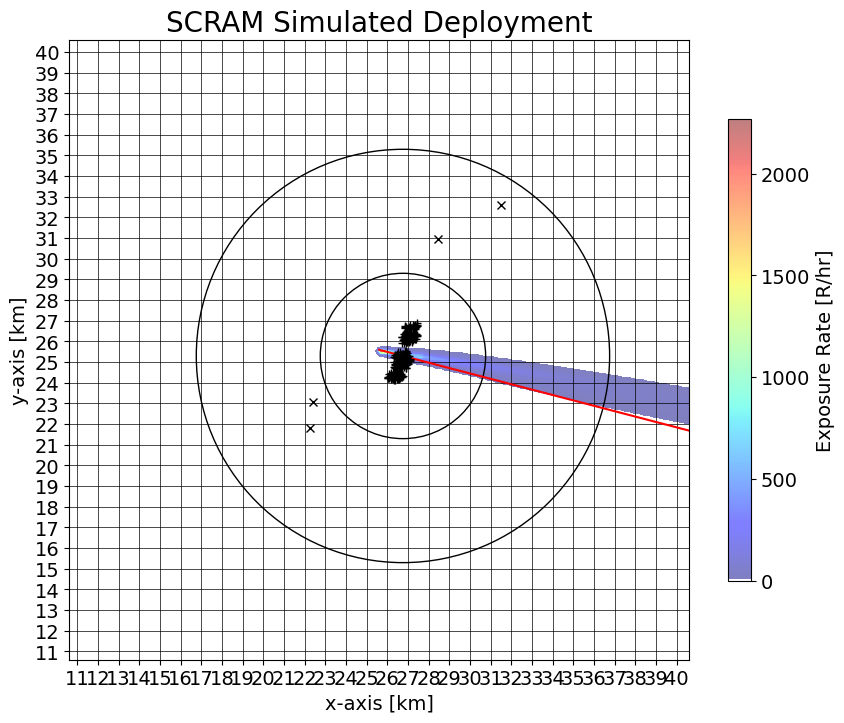

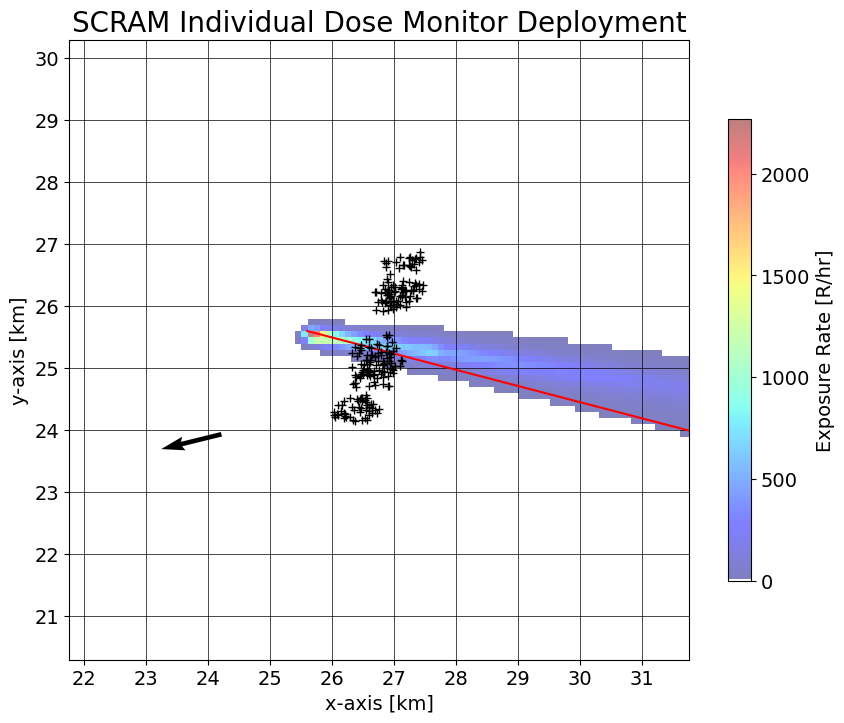

In [8]:
from datetime import datetime
##generate a sample field and plot it
randIndex = np.random.randint(0, len(falloutFields))
falloutfield, falloutDir = getFieldData(falloutFields[0])
# Apply global font settings
plt.rcParams['font.size'] = 14
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.titlesize'] = 20

hr=0
fig = plotField(radfield=falloutfield[hr],falloutDirection=falloutDir, pixelScale=.1, visibleRadius=15)

SCARM_Parameters = {'nArtyShells'        : 10, # number of artillery shells
                    'ArtyMinRange'       : 15, # minimum range of artillery [km]
                    'ArtyMaxRange'       : 40, # maximum range of artillery [km]
                    'ArtyFieldWidth'     :1.5, # width of the artillery field [km]
                    'ArtyFieldDepth'     : .2, # length of the artillery field [km]
                    'ArtyFieldRotation'  : 90, # angle of the artillery field from the fallout direction [degrees]
                    'nDetPerShell'       : 24, # number of detectors per shell
                    'DetDispersionWidth' : .2, # width of the detector dispersion [km]
                    'DetDispersionLength': .4, # length of the detector dispersion [km]
                    'nGateways'          :  4, # number of gateways
                    'GatewayMaxRange'    : 10, # maximum range of gateways [km]
                    'GatewayMinRange'    :  4, # minimum range of gateways [km]
                    'GatewayMaxExposure' : 50, # maximum exposure of gateways locations
                    'GatewayMinSeparation': 2, # minimum separation between gateways [km]
                    }

minDistFromGZ = 1  # minimum distance from ground zero [km]
maxDistFromGZ = 5 # maximum distance from ground zero [km]
distFromGZ = np.random.uniform(minDistFromGZ, maxDistFromGZ)

detectorLocations, gatewayLocations, detFieldCenter, artyDir = genDetectorField(falloutfield, .1, falloutDir, SCARM_Parameters, distFromGZ)
fig = plotGateways(fig, gatewayLocations, detFieldCenter=detFieldCenter, params=SCARM_Parameters)
fig = plotDetectors(fig, detectorLocations)
plt.title('SCRAM Simulated Deployment')
plt.xlabel('x-axis [km]')
plt.ylabel('y-axis [km]')
#add a time stamp to the saved plot
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
#plt.savefig(f'{plotDirectory}SCRAM LP Deployment_{timestamp}.png', dpi=300, bbox_inches='tight')  # Save with 300 dpi for higher resolution

plt.show()

fig = plotField(radfield=falloutfield[hr], falloutDirection=falloutDir, pixelScale=.1, visibleRadius=5, plotCenter=detFieldCenter)
fig = plotDetectors(fig, detectorLocations, artyDir)
plt.title('SCRAM Individual Dose Monitor Deployment')
plt.xlabel('x-axis [km]')
plt.ylabel('y-axis [km]')
#plt.savefig(f'{plotDirectory}SCRAM IDM Deployment_{timestamp}.png', dpi=300, bbox_inches='tight')  # Save with 300 dpi for higher resolution
plt.show()


In [9]:
print(len(falloutFields))
print(falloutfield.shape)

160
(93, 512, 512)


In [9]:
a = falloutfield[0]
# create a list of 93 from a 93,512x512 array
b = a.flatten()

# GIF of One Fallout Distribution over time

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
max_time = 24
time = 1
time_steps = 0.25
counts=[]
while time <= max_time:
    #print(time)
    #self.overlay_data.insert(0,[3,4,0,0,float(val)])
    counts.append(time)
    time += time_steps
# Assuming you have a 3D numpy array of shape (93, 512, 512)

##plot the fallout field
cmap = plt.cm.jet
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[0] = (1, 1, 1, 1.0)
cmap = mcolors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)



array_3d = falloutfield  # Replace this with your actual data

crop_size = 300

# Crop the bottom-right corner of the 3D array
# This assumes the image is at least 512x512; adjust the crop indices as needed.
array_3d = array_3d[:, -crop_size:, :crop_size]

# Calculate global min and max values for consistent color scaling
vmin = array_3d.min()
#vmax = array_3d.max()
vmax = 150
# Create a directory to store the frames (you can choose a different directory)
if not os.path.exists('frames'):
    os.makedirs('frames')

# Generate and save each plot as a frame
filenames = []
for i in range(array_3d.shape[0]):
    plt.imshow(array_3d[i], cmap=cmap, interpolation='none', vmin=vmin, vmax=vmax)

    colorbar = plt.colorbar(orientation='vertical')

    colorbar.set_label('Exposure Rate [R/hr]')
    plt.title(f"Exposure Rate H+{counts[i]} hrs")
    plt.xlabel('x-axis [km]')
    plt.ylabel('y-axis [km]')
    # Save the plot to a file
    filename = f"frames/frame_{i}.png"
    filenames.append(filename)
    plt.savefig(filename)
    plt.close()  # Close the figure to avoid memory issues

# Create a GIF using the saved frames
with imageio.get_writer('output.gif', mode='I', duration=1) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

# Clean up the frame images if you don't need them anymore
for filename in filenames:
    os.remove(filename)

print("GIF has been saved as 'output.gif'")


ModuleNotFoundError: No module named 'imageio'

# Figures of Fallout for Sam's Paper

0
Yield (kt): 100
HOB (m): 0
Surface Wind Speed (m/s): 15
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


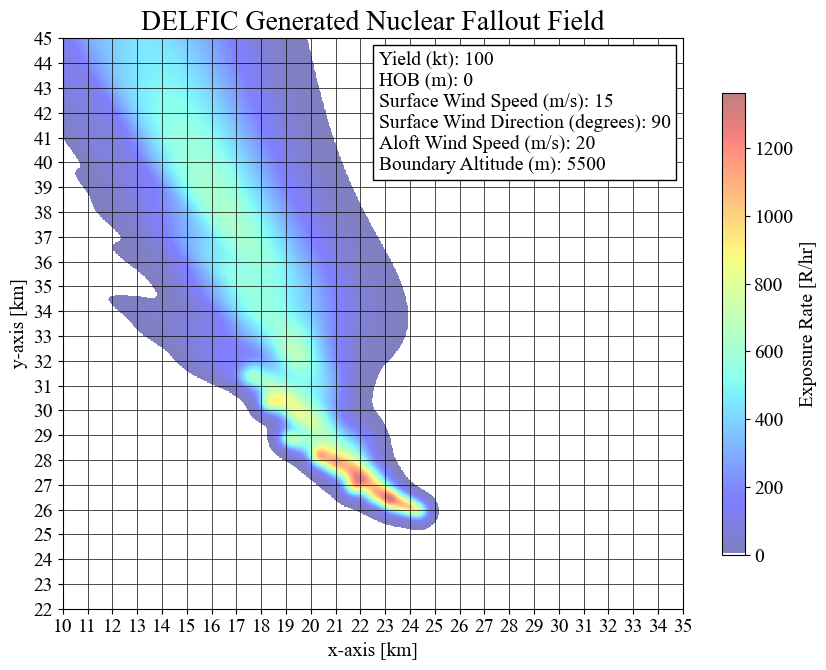

1
Yield (kt): 100
HOB (m): 0
Surface Wind Speed (m/s): 25
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


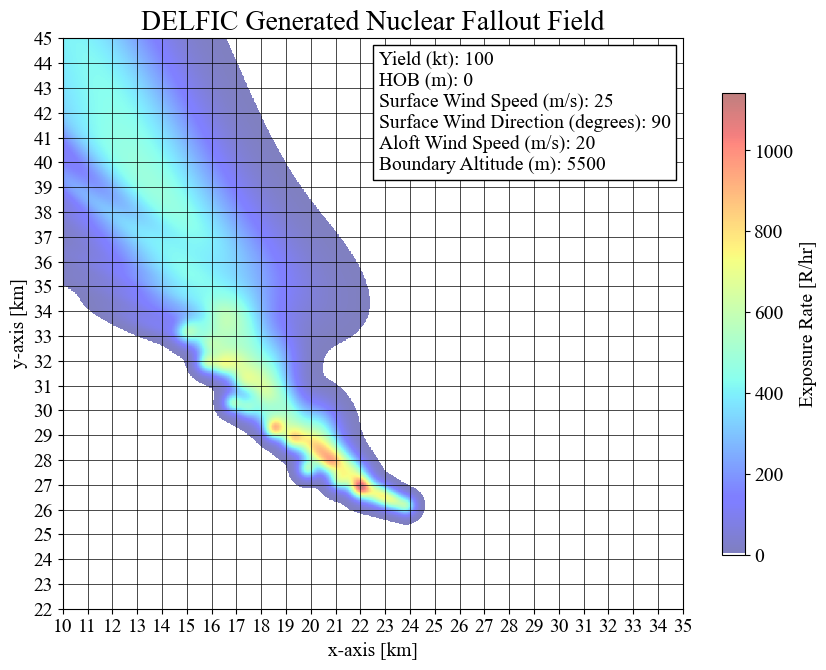

2
Yield (kt): 100
HOB (m): 0
Surface Wind Speed (m/s): 5
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


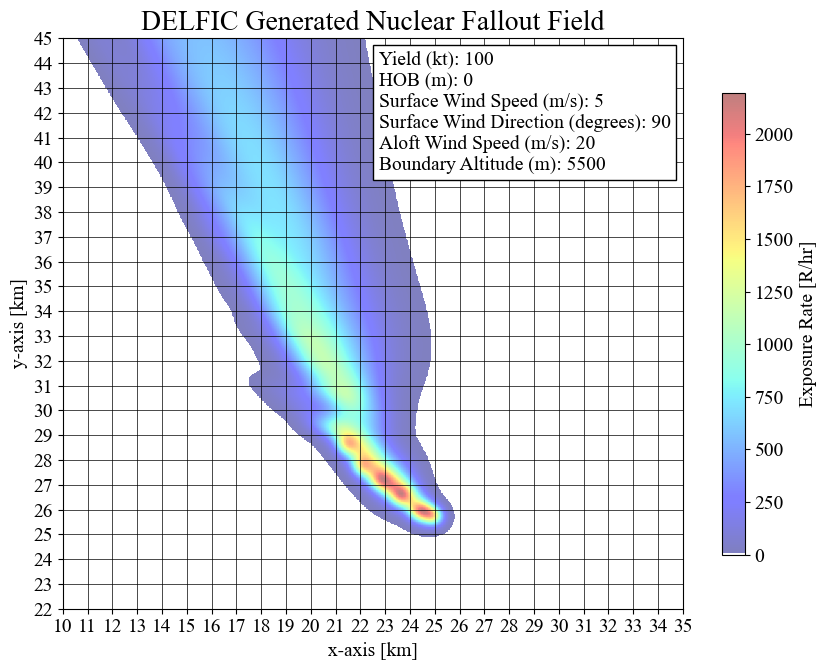

3
Yield (kt): 100
HOB (m): 0
Surface Wind Speed (m/s): 7
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


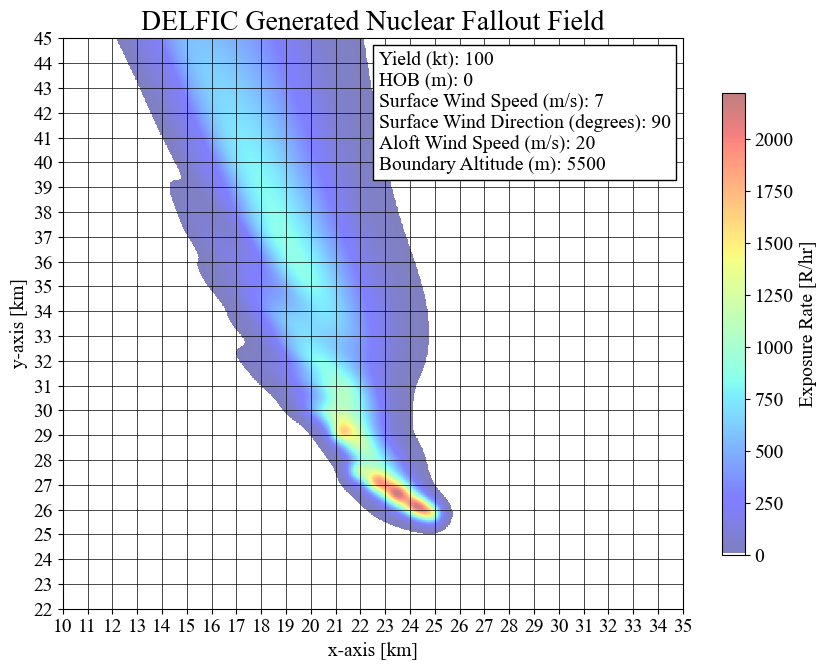

4
Yield (kt): 100
HOB (m): 1000
Surface Wind Speed (m/s): 7
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


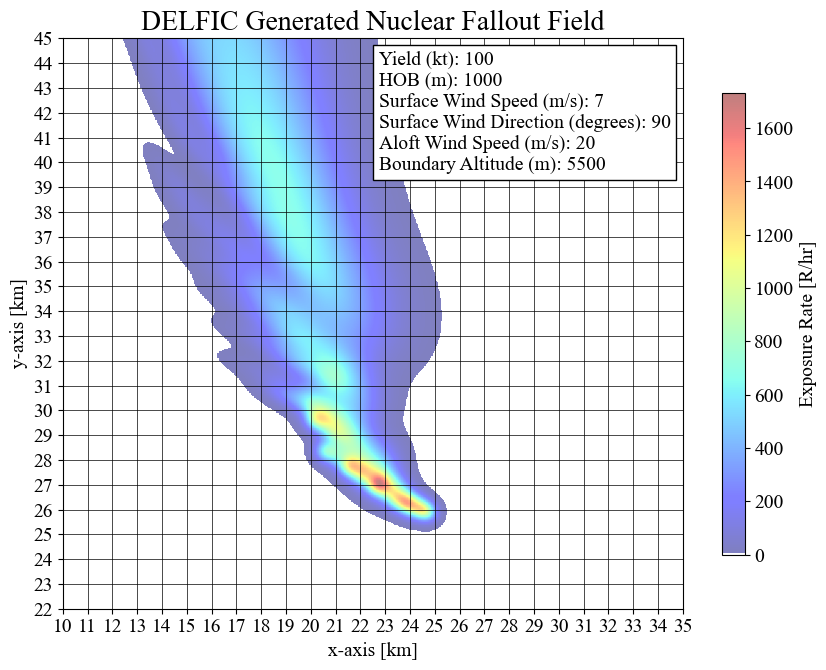

5
Yield (kt): 100
HOB (m): 10
Surface Wind Speed (m/s): 7
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


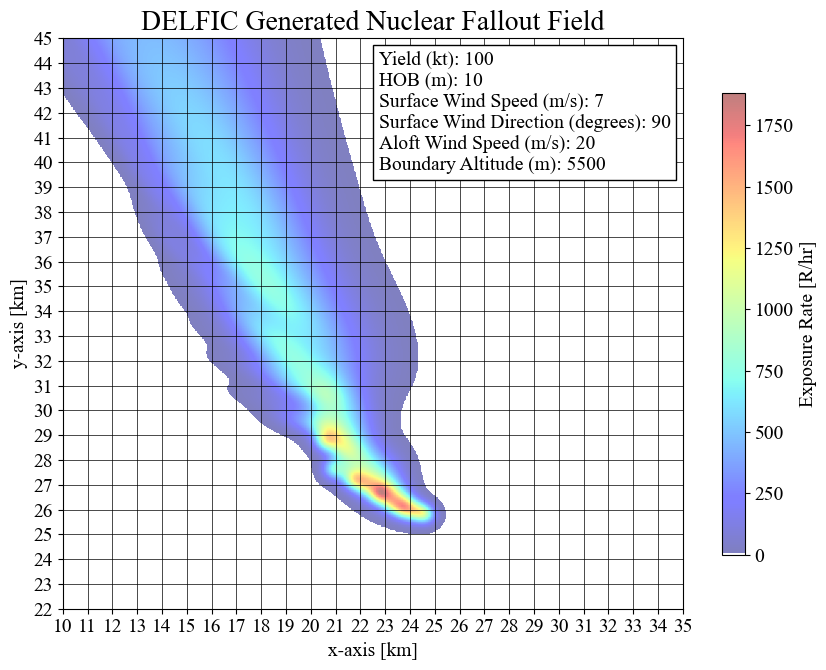

6
Yield (kt): 100
HOB (m): 5000
Surface Wind Speed (m/s): 7
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


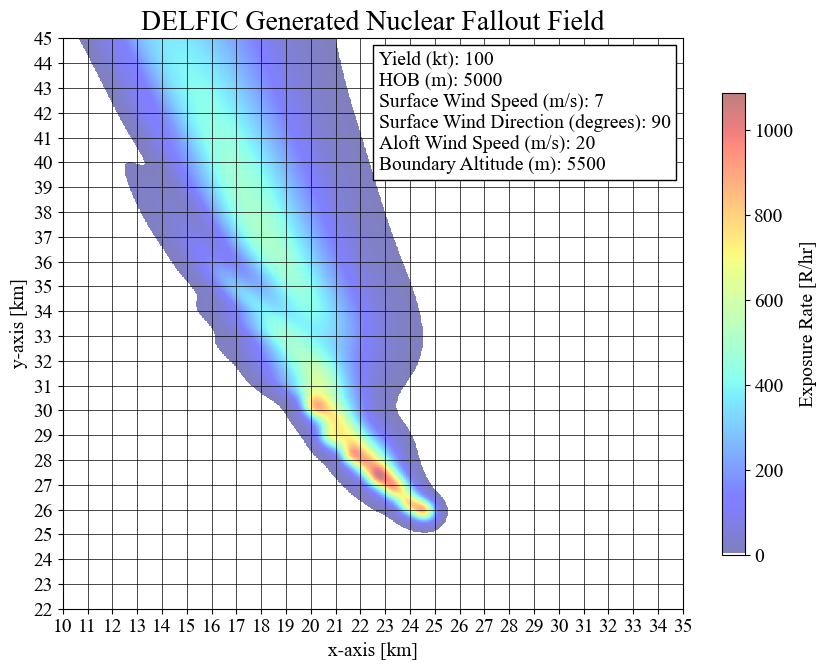

7
Yield (kt): 500
HOB (m): 0
Surface Wind Speed (m/s): 7
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


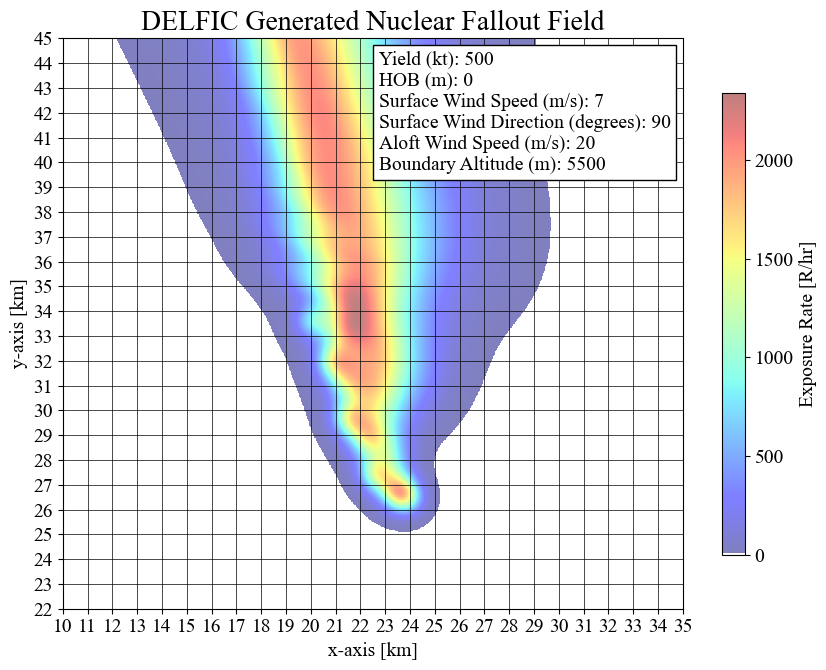

8
Yield (kt): 50
HOB (m): 0
Surface Wind Speed (m/s): 7
Surface Wind Direction (degrees): 90
Aloft Wind Speed (m/s): 20
Boundary Altitude (m): 5500


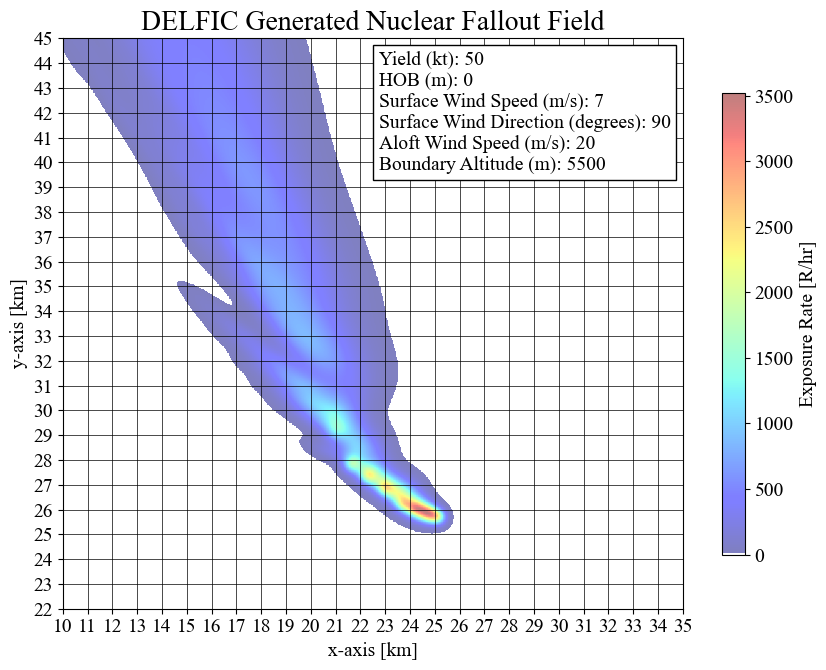

In [8]:
import os
import re

plot_folder = 'C:/Users/kev/documents/DELFIC_Sam_Plots/'  # Folder that Sam's plot are saved in

falloutSamPlots = [f for f in os.listdir(plot_folder) if os.path.isdir(os.path.join(plot_folder, f))]
for i in enumerate(falloutSamPlots):
    print(i[0])
    plot_num = i[0]
    falloutfield, falloutDir = getFieldData(falloutSamPlots[plot_num],sourceDirectory=plot_folder)
    # extract the yield as the three characters after Y
    fig = plotField(radfield=falloutfield[0],falloutDirection=falloutDir, pixelScale=.1, visibleRadius=15,addLine=False)

    fallout_Name = falloutSamPlots[plot_num]
    # Define a pattern to match a letter followed by a number (supports multi-digit numbers)
    pattern = r'([A-Z]+)(\d+)'

    # Find all matches (pairs of letters and numbers)
    matches = re.findall(pattern, fallout_Name)
    custom_descriptors = {
        'Y': 'Yield (kt)',
        'H': 'HOB (m)',
        'SS': 'Surface Wind Speed (m/s)',
        'DS': 'Surface Wind Direction (degrees)',
        'SA': 'Aloft Wind Speed (m/s)',
        'BA': 'Boundary Altitude (m)'
    }
    # Create a dictionary to store the results
    variables = {custom_descriptors.get(letter, letter): int(number) for letter, number in matches}
    # Now you can access each variable by its letter

    for descriptor, number in variables.items():
        print(f"{descriptor}: {number}")

    plt.title('DELFIC Generated Nuclear Fallout Field')
    plt.xlabel('x-axis [km]')
    plt.ylabel('y-axis [km]')
    # Create a custom legend entry with the descriptors and corresponding numbers
    custom_legend = '\n'.join([f"{descriptor}: {number}" for descriptor, number in variables.items()])

    # Add the custom legend as a text box
    plt.text(0.51, 0.87, custom_legend, transform=plt.gca().transAxes, fontsize=14,
            verticalalignment='center', bbox=dict(facecolor='white', alpha=1))


    plt.xlim([10, 35])  # Replace xmin and xmax with your desired limits
    plt.ylim([22, 45])
    plt.savefig(f'{plot_folder}DELFIC_{fallout_Name}_{timestamp}.png', dpi=300, bbox_inches='tight')  # Save with 300 dpi for higher resolution

    plt.show()


# Exponential Fit Functions

In [ ]:
##fit exponential functions to each pixel of relavance
from math import exp
from scipy.optimize import curve_fit

##determine the pixels that the detectors are in
def getDetectorPixels(detectorLocations, pixelScale):
  detectorPixels = set()
  for detector in detectorLocations:
    #determine the 4 surrounding pixels
    x = trunc(detector[0]/pixelScale)
    y = trunc(detector[1]/pixelScale)

    detectorPixels.add((x, y))
    detectorPixels.add((x+1, y))
    detectorPixels.add((x, y+1))
    detectorPixels.add((x+1, y+1))

  return list(detectorPixels)

def doubleExponential(t, a, b, c, d):
    # Clip the exponent to avoid overflow
    clipped_b_t = np.clip(-b * t, -700, 700)
    clipped_d_t = np.clip(-d * t, -700, 700)
    return a * np.exp(clipped_b_t) + c * np.exp(clipped_d_t)
  
def getExpFitParams(data, detectorLocations, pixelScale):
  pixels = getDetectorPixels(detectorLocations, pixelScale)

  #fit the exponential function to a representative pixel
  x = np.arange(0, data.shape[0], 1)
  y = data[:, pixels[0][1], pixels[0][0]]

  popt, pcov = curve_fit(doubleExponential, x, y, p0=[1, 1, 1, 1])

  ##fit the exponential function to all the pixels
  fitExpParams = {}
  x = np.arange(0, data.shape[0], 1)
  cutoff = 10
  for pixel in pixels:
    y = data[:, pixel[1], pixel[0]]
    if np.max(y) < cutoff:
      continue
    try:
      popt, pcov = curve_fit(doubleExponential, x, y, p0=[1, 1, 1, 1], bounds=([0, 0, 0, 0], [1e10, 1e10, 1e10, 1e10]))
      fitExpParams[pixel] = popt
    except:
      pass

  return fitExpParams

##for each detector, determine the exposure rate at all times using interpolation
def getDetectorExposure(detectorLocations, fieldExpParams, pixelScale, timesteps):
  detectorExposure = np.zeros((len(timesteps), len(detectorLocations)))
  for d, detector in enumerate(detectorLocations):
    x = trunc(detector[0]/pixelScale)
    y = trunc(detector[1]/pixelScale)

    surroundingPixels = [(x, y), (x+1, y), (x, y+1), (x+1, y+1)] #the 4 surrounding pixels

    for t, timestep in enumerate(timesteps):
      knownExposureRates = np.zeros(4) #exposure rates for the 4 surrounding pixels
      for p, pixel in enumerate(surroundingPixels):
        if pixel in fieldExpParams:
          knownExposureRates[p] = doubleExponential(timestep, *fieldExpParams[pixel])

      #interpolate the exposure rate
      x0 = x * pixelScale
      y0 = y * pixelScale
      x1 = x0 + pixelScale
      y1 = y0 + pixelScale

      _x = detector[0]
      _y = detector[1]

      #interpolate the exposure rate
      detectorExposure[t, d] = ((x1 - _x) * (y1 - _y) * knownExposureRates[0] +
                                (_x - x0) * (y1 - _y) * knownExposureRates[1] +
                                (x1 - _x) * (_y - y0) * knownExposureRates[2] +
                                (_x - x0) * (_y - y0) * knownExposureRates[3]) / (pixelScale**2)
  return detectorExposure

nTimesteps = 100
timesteps = np.linspace(0, falloutfield.shape[0], nTimesteps)
fitExpParams = getExpFitParams(falloutfield, detectorLocations, .1)
detectorExposures = getDetectorExposure(detectorLocations, fitExpParams, .1, timesteps)

In [9]:
##get detector exposure without exponential fitting

##for each detector, determine the exposure rate at all times using interpolation
def getDetectorExposures(detectorLocations, falloutfield, pixelScale):
  nTimesteps = falloutfield.shape[0]
  nDetectors = len(detectorLocations)
  detectorExposures = np.zeros( (nTimesteps, nDetectors) )

  for d, detLoc in enumerate(detectorLocations):
    x = trunc(detLoc[0]/pixelScale)
    y = trunc(detLoc[1]/pixelScale)

    for t in range(nTimesteps):
      # interpolate the exposure rate using the 4 surrounding pixels
      detectorExposures[t, d] = ((x+1 - detLoc[0]/pixelScale) * (y+1 - detLoc[1]/pixelScale) * falloutfield[t, y, x] +
                                 (detLoc[0]/pixelScale - x) * (y+1 - detLoc[1]/pixelScale) * falloutfield[t, y, x+1] +
                                 (x+1 - detLoc[0]/pixelScale) * (detLoc[1]/pixelScale - y) * falloutfield[t, y+1, x] +
                                 (detLoc[0]/pixelScale - x) * (detLoc[1]/pixelScale - y) * falloutfield[t, y+1, x+1])
      
  return detectorExposures

detectorExposures = getDetectorExposures(detectorLocations, falloutfield, .1)

In [10]:
##for each detector, determine the predicted location for each timestep
from simSCRAM_detector import SimDetector
from SCRAM_field import Gateway

gateways = []
for g, gateway in enumerate(gatewayLocations):
  gateways.append(Gateway(gateway[0], gateway[1], g))

detectorField = []
nTimesteps = falloutfield.shape[0]
timescale = 0.25
for d, detector in enumerate(detectorLocations):
  detectorField.append(SimDetector(detector[0], detector[1], 
                                   detectorExposures[:, d], d, gateways,
                                   nTimesteps, timescale))

from multiprocessing import Pool
#wrapper function to process each detector for each timestep in parallel
def processDetector(detector):
  detector.mp()
  return detector

with Pool(128) as p:
  detectorField = p.map(processDetector, detectorField)


TypeError: minimize() missing 1 required positional argument: 'x0'

## Editing above but for windows

In [70]:
##for each detector, determine the predicted location for each timestep
from simSCRAM_detector import SimDetector
from SCRAM_field import Gateway

gateways = []
for g, gateway in enumerate(gatewayLocations):
  gateways.append(Gateway(gateway[0], gateway[1], g))

detectorField = []
for d, detector in enumerate(detectorLocations):
  detectorField.append(SimDetector(detector[0], detector[1], 
                                   detectorExposures[:, d], d, gateways,
                                   nTimesteps, timeScale=0.25))
  
  #Windows short run


detectorField = list(map(lambda det: processDetector(det),detectorField))


KeyboardInterrupt: 

In [10]:
from multiprocessing import Pool
from SCRAM_field import Gateway
from simSCRAM_detector import SimDetector

def processDetector(detector):
  detector.mp()
  return detector

def processDetectors(detectorLocations, gatewayLocations, detectorExposures, nTimesteps, timeScale, pool):
  gateways = []
  for g, gateway in enumerate(gatewayLocations):
    gateways.append(Gateway(gateway[0], gateway[1], g))

  detectorField = []
  for d, detector in enumerate(detectorLocations):
    detectorField.append(SimDetector(detector[0], detector[1], 
                                    detectorExposures[:, d], d, gateways,
                                    nTimesteps, timeScale))

  detectorField = pool.map(processDetector, detectorField)
  return detectorField

Y1H16SS3DS257SA18BA6019


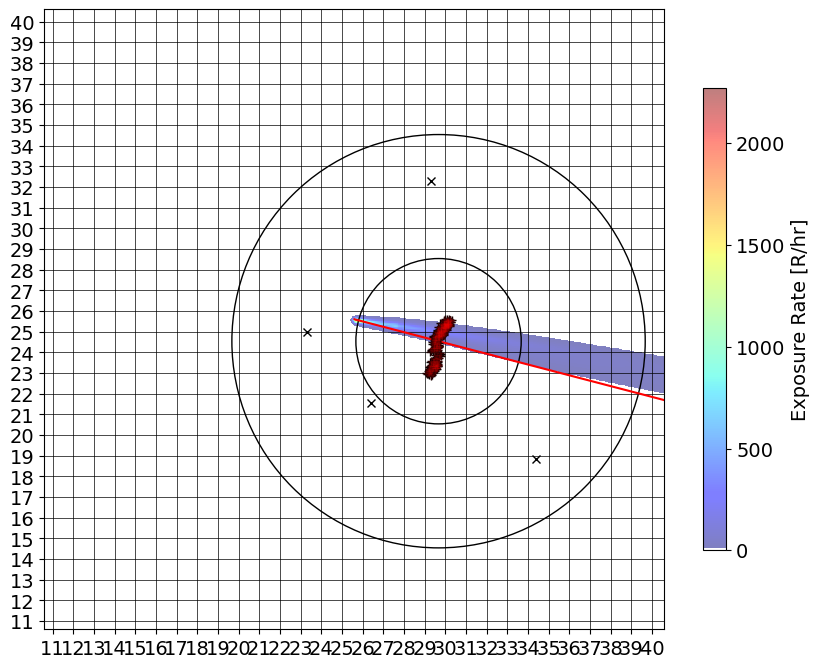

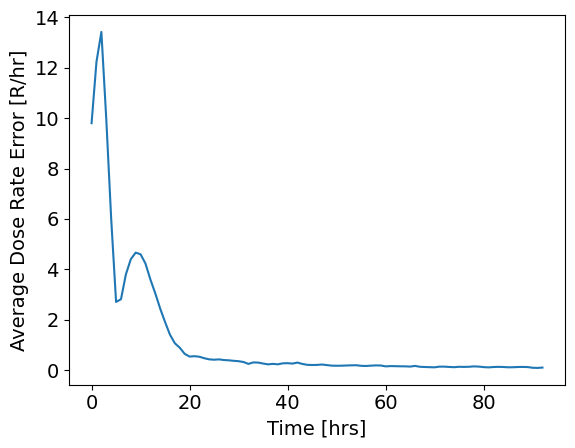

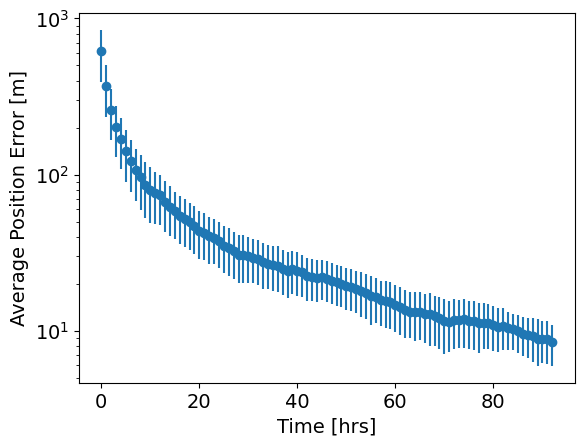

In [35]:
##confirm the results
from turtle import st


randIndex = np.random.randint(0, len(falloutFields))
print(falloutFields[randIndex])
falloutfield, falloutDir = getFieldData(falloutFields[randIndex])

distFromGZ = np.random.uniform(minDistFromGZ, maxDistFromGZ)
detectorLocations, gatewayLocations, detFieldCenter, artyDir = genDetectorField(falloutfield, .1, falloutDir, SCARM_Parameters, distFromGZ)
fig = plotField(radfield=falloutfield[0], falloutDirection=falloutDir, pixelScale=.1, visibleRadius=15) #first time step
fig = plotGateways(fig, gatewayLocations, detFieldCenter=detFieldCenter, params=SCARM_Parameters)
fig = plotDetectors(fig, detectorLocations)

detectorExposures = getDetectorExposures(detectorLocations, falloutfield, .1)
with Pool(128) as p:
  detectorField = processDetectors(detectorLocations, gatewayLocations, detectorExposures, falloutfield.shape[0], 0.25, p)

nTimesteps = falloutfield.shape[0]
for d in detectorField:
  plt.plot(d.measuredX[nTimesteps-1], d.measuredY[nTimesteps-1], 'r+', alpha=0.1)
plt.show()

#plot the average dose rate and position error for the array of detectors
avgDoseError = np.zeros(nTimesteps)
stdDevDoseError = np.zeros(nTimesteps)
avgPosError = np.zeros(nTimesteps)
stdDevPosError = np.zeros(nTimesteps)
for t in range(nTimesteps):
  avgDoseError[t] = np.mean([np.abs(det.estimatedDoseRateMeasurements[t]-det.trueDoseRates[t]) for det in detectorField])
  stdDevDoseError[t] = np.std([np.abs(det.estimatedDoseRateMeasurements[t]-det.trueDoseRates[t]) for det in detectorField])
  avgPosError[t] = np.mean([np.linalg.norm([det.measuredX[t]-det.trueX, det.measuredY[t]-det.trueY]) for det in detectorField])
  stdDevPosError[t] = np.std([np.linalg.norm([det.measuredX[t]-det.trueX, det.measuredY[t]-det.trueY]) for det in detectorField])

plt.plot(avgDoseError)
plt.xlabel('Time [hrs]')
plt.ylabel('Average Dose Rate Error [R/hr]')
plt.show()

plt.errorbar(np.arange(nTimesteps), avgPosError*1000, yerr=stdDevPosError*1000, fmt='o')
plt.xlabel('Time [hrs]')
plt.ylabel('Average Position Error [m]')
plt.yscale('log')
plt.show()




## Getting some average values of the position

In [86]:
detectorField[161].measuredX[23]
#detectorField[161].trueX
x_meas = detectorField[161].measuredX[99]

y_meas = detectorField[161].measuredY[99]
trueY = detectorField[161].trueY


In [87]:
distance = np.sqrt((x_meas  - detectorField[161].trueX)**2 + (y_meas - detectorField[161].trueY)**2)


In [94]:
# for each detector I want to get the average distance based on the last [99th] element of measuredX
# and measuredY
vals = []
for i in range(len(detectorField)):
    x_meas = detectorField[i].measuredX[99]
    y_meas = detectorField[i].measuredY[99]
    trueX = detectorField[i].trueX
    trueY = detectorField[i].trueY
    distance = np.sqrt((x_meas - trueX)**2 + (y_meas - trueY)**2)*1000
    vals.append(distance)
    #print(f"Detector {i}: {distance:.2f} m")
print(np.average(vals))
print(max(vals))
print(min(vals))

14.264512567154783
29.750906670188716
1.6224503341265823


## Another Windows instance to test a different exponential fit, now deleted

In [29]:
##for each detector, determine the predicted location for each timestep
from simSCRAM_detector import SimDetector
from SCRAM_field import Gateway

gateways = []
for g, gateway in enumerate(gatewayLocations):
  gateways.append(Gateway(gateway[0], gateway[1], g))

detectorField3 = []
for d, detector in enumerate(detectorLocations):
  detectorField3.append(SimDetector(detector[0], detector[1], 
                                   detectorExposures[:, d], d, gateways,
                                   timesteps))
detectorField3 = list(map(lambda det: processDetector(det),detectorField3))


In [89]:

##confirm the results
randDet = np.random.randint(0, len(detectorField3))
print(randDet)
detectorField3[randDet].plotDistanceError(*detectorLocations[randDet])
detectorField3[randDet].plotDoseRate(detectorField3[randDet].trueDoseRates)

NameError: name 'detectorField3' is not defined

In [36]:
##loop the process to build a training library
import os
falloutFields = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

nSimulations = len(falloutFields)
nTimesteps   = falloutfield.shape[0]
timescale    = 0.25
nRunsPerSim  = 20
extimatedPixels = 4*SCARM_Parameters['nDetPerShell']*SCARM_Parameters['nArtyShells']

minDistFromGZ = 2  # minimum distance from ground zero [km]
maxDistFromGZ = 10 # maximum distance from ground zero [km]
pixelScale = .1

timesteps = np.linspace(0, falloutfield.shape[0], nTimesteps)

SCARM_Parameters = {'nArtyShells'        : 10, # number of artillery shells
                    'ArtyMinRange'       : 15, # minimum range of artillery [km]
                    'ArtyMaxRange'       : 40, # maximum range of artillery [km]
                    'ArtyFieldWidth'     :1.5, # width of the artillery field [km]
                    'ArtyFieldDepth'     : .2, # length of the artillery field [km]
                    'ArtyFieldRotation'  : 90, # angle of the artillery field from the fallout direction [degrees]
                    'nDetPerShell'       : 24, # number of detectors per shell
                    'DetDispersionWidth' : .2, # width of the detector dispersion [km]
                    'DetDispersionLength': .4, # length of the detector dispersion [km]
                    'nGateways'          :  4, # number of gateways
                    'GatewayMaxRange'    : 10, # maximum range of gateways [km]
                    'GatewayMinRange'    :  4, # minimum range of gateways [km]
                    'GatewayMaxExposure' : 50, # maximum exposure of gateways locations
                    'GatewayMinSeparation': 2, # minimum separation between gateways [km]
                    }

with Pool(128) as p:
  #for each DELFIC simulation:
  for falloutField in falloutFields:

    #check for the *_X file in ../data/
    # if it exists, skip the simulation
    if os.path.exists(f'../data/{falloutField}_X.npy'):
      continue 

    #data strucutre to hold the training data
    # X = [nSimulations * nRunsPerSim, nTimesteps, nDetectors, 5] #detector data
    X  = np.zeros((nRunsPerSim, SCARM_Parameters['nArtyShells']*SCARM_Parameters['nDetPerShell'], nTimesteps, 5)) #X, Y, dR, Dose, dDose
    Yr = np.zeros((nRunsPerSim, SCARM_Parameters['nArtyShells']*SCARM_Parameters['nDetPerShell'], 2)) #X, Y
    Yd = np.zeros((nRunsPerSim, SCARM_Parameters['nArtyShells']*SCARM_Parameters['nDetPerShell'], nTimesteps)) #Dose Rate
    
    #execute a number of detector scattering runs
    falloutFieldData, falloutDir = getFieldData(falloutField)

    #Y[falloutField] = {}
    for j in range(nRunsPerSim):
      success = False
      while not success:
        try:
          distFromGZ = np.random.uniform(minDistFromGZ, maxDistFromGZ)
          detectorLocations, gatewayLocations, detFieldCenter, artyDir = genDetectorField(falloutFieldData, pixelScale, falloutDir, SCARM_Parameters, distFromGZ)
          #fitExpParams = getExpFitParams(falloutFieldData, detectorLocations, pixelScale)

          #found the parameters, break the loop
          success = True
        except Exception as e:
          print(e)
      
      #detectorExposures = getDetectorExposure(detectorLocations, fitExpParams, pixelScale, timesteps)
      detectorExposures = getDetectorExposures(detectorLocations, falloutFieldData, pixelScale)
      gateways = []
      for g, gateway in enumerate(gatewayLocations):
        gateways.append(Gateway(gateway[0], gateway[1], g))

      detectorField = []
      for d, detector in enumerate(detectorLocations):
        detectorField.append(SimDetector(detector[0], detector[1], 
                                        detectorExposures[:, d], d, gateways,
                                        nTimesteps, timescale))
        
      detectorField = p.map(processDetector, detectorField)
      for d, detector in enumerate(detectorField):
        X[j, d] = detector.getFeatures(nTimesteps).T
        Yr[j, d, 0] = detectorField[d].trueX
        Yr[j, d, 1] = detectorField[d].trueY
      Yd[j] = detectorExposures.T

    ##save the data
    np.save(f'../data/{falloutField}_X.npy', X)
    np.save(f'../data/{falloutField}_Yr.npy', Yr)
    np.save(f'../data/{falloutField}_Yd.npy', Yd)
      



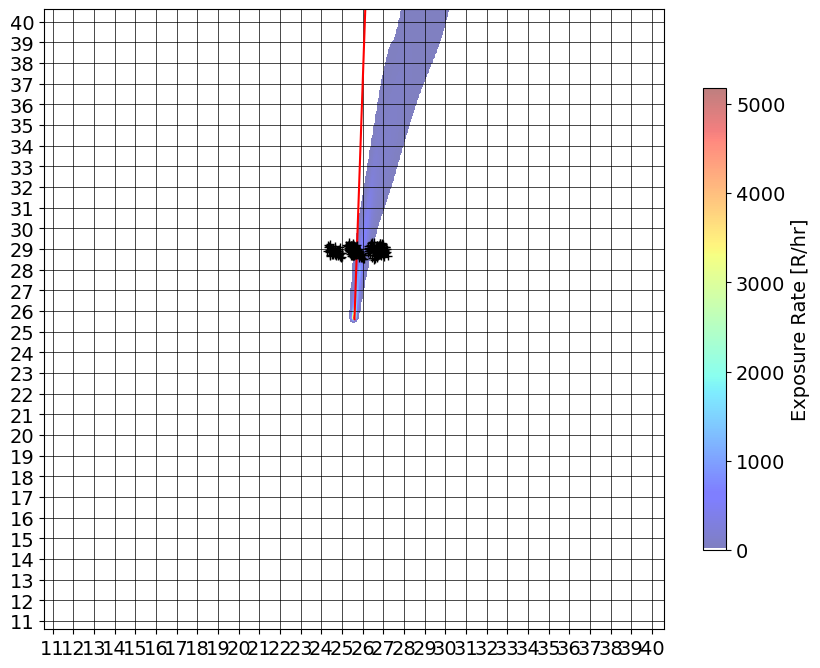

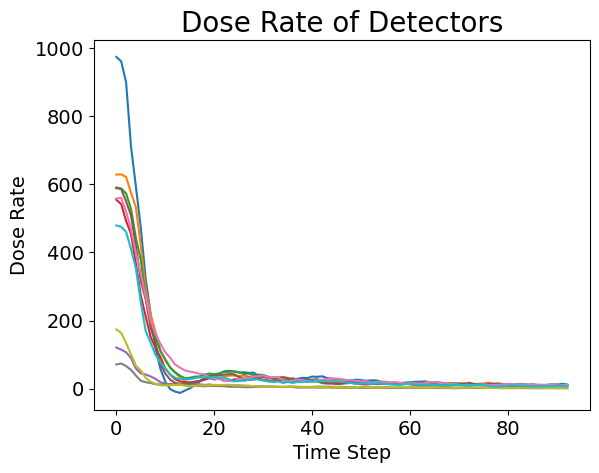

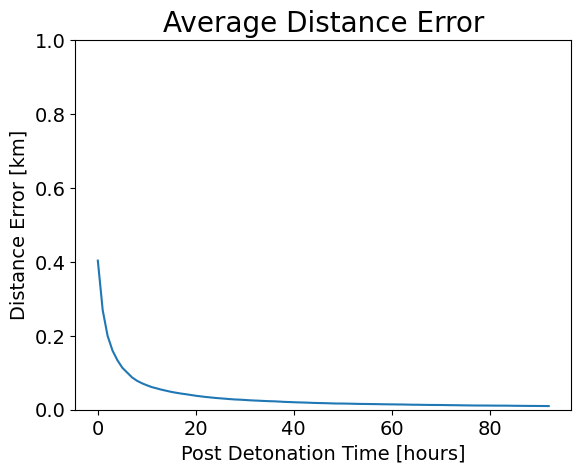

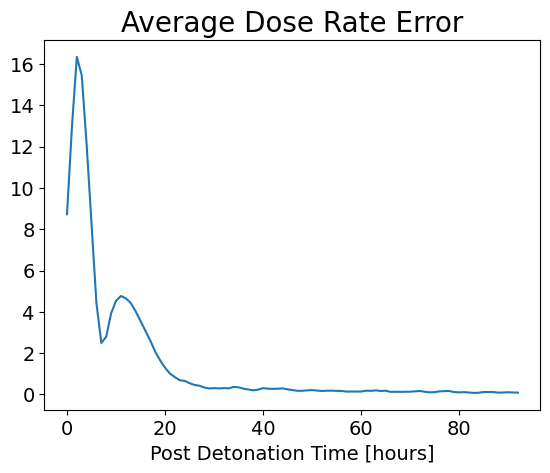

In [38]:
import numpy as np
import matplotlib.pyplot as plt

falloutfieldName = 'Y1H0SS3DS163SA19BA4431'

#open a sample file
x = np.load(f'../data/{falloutfieldName}_X.npy', allow_pickle=True)

# X is of form [nSim, timestep, nDet, features]
#the 6 features are: x, y, dPos, dose, dDose, detNum

falloutfield, falloutDir = getFieldData(falloutfieldName)
fig = plotField(radfield=falloutfield[0], falloutDirection=falloutDir, pixelScale=.1, visibleRadius=15)

#plot the final x and y positions of the detectors
sim = 19
timestep = -1
plt.plot(x[sim, :, timestep, 0], x[sim, :, timestep, 1], 'k+')
plt.show()

# plot the dose of the first 10 detectors across time
for i in range(10):
    plt.plot(x[sim, i, :, 3], label=f'Detector {i}')
plt.title('Dose Rate of Detectors')
plt.xlabel('Time Step')
plt.ylabel('Dose Rate')
plt.show()

#determine the average distance error as a function of time and plot it
from simSCRAM_detector import SimDetector

#open the Y file
yr = np.load(f'../data/{falloutfieldName}_Yr.npy', allow_pickle=True)

# Y is of form [nSim, nDet, 2]
#the 2 features are: x, y

nDets = yr.shape[1]
distanceErrors = np.zeros((nDets, nTimesteps))
for i in range(nDets):
    for j in range(nTimesteps):
        distanceErrors[i, j] = np.linalg.norm(x[sim, i, j, :2] - yr[sim, i])

plt.plot(np.mean(distanceErrors, axis=0))
plt.ylim(0, 1)

#the timesteps are evenly spaced across 24 hours
#set the ticks to be every 2 hours
#plt.xticks(np.arange(0, nTimesteps, nTimesteps//12), np.arange(0, 25, 2))
plt.title('Average Distance Error')
plt.xlabel('Post Detonation Time [hours]')
plt.ylabel('Distance Error [km]')
plt.show()

#determine the average dose rate error as a function of time and plot it
#open the Y file
yd = np.load(f'../data/{falloutfieldName}_Yd.npy', allow_pickle=True)

# Y is of form [nSim, nDet, nTimesteps]
#the 1 feature is: dose rate

nDets = yd.shape[1]
doseRateErrors = np.zeros((nDets, nTimesteps))
for i in range(nDets):
    for j in range(nTimesteps):
        doseRateErrors[i, j] = np.abs(x[sim, i, j, 3] - yd[sim, i, j])

plt.plot(np.mean(doseRateErrors, axis=0))
#plt.xticks(np.arange(0, nTimesteps, nTimesteps//12), np.arange(0, 25, 2))
plt.title('Average Dose Rate Error')
plt.xlabel('Post Detonation Time [hours]')
plt.show()